In [2]:
# Step A: Connect Colab to your Google Drive account
from google.colab import drive
drive.mount('/content/drive')

# Step B: Point Python directly to the 'Data' subfolder where your files live
import os
os.chdir('/content/drive/MyDrive/AI_Tool_Adoption_Analysis_Project/Data')

# Step C: Read the dataset file sitting next to this notebook
import pandas as pd
df = pd.read_csv("AI_Adoption_Research_Grade_350.csv")

# Step D: Display the first 5 rows of your data to confirm it works
df.head()

Mounted at /content/drive


,Organization_ID,Industry,Company_Size,Employee_Count,AI_Tool,Adoption_Year,AI_Adoption_Score,Monthly_AI_Users,Productivity_Gain_Percent,Satisfaction_Score,AI_Investment_USD,Annual_Cost_Savings_USD,ROI_Percent,Training_Hours_Per_Employee,Automation_Level_Percent
0,ORG0001,Manufacturing,Medium,522,Claude,2025,76,206,50.31,7.6,48016.29,93254.21,94.21,30,80
1,ORG0002,Manufacturing,Small,116,Cursor,2021,56,27,31.51,2.5,24307.60,59121.97,143.22,53,48
2,ORG0003,Finance,Medium,380,GitHub Copilot,2023,84,100,39.27,4.3,68441.93,137213.19,100.48,15,91
3,ORG0004,Retail,Small,35,Cursor,2024,61,14,32.68,4.3,7718.52,13394.36,73.54,80,68
4,ORG0005,Marketing,Small,121,Gemini,2024,78,25,53.08,7.4,18492.33,32151.76,73.87,54,85


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display all columns
pd.set_option('display.max_columns', None)

df = pd.read_csv("AI_Adoption_Research_Grade_350.csv")

# it will describe the mean, median, std (statistical measure)
df.describe()

numerical_columns = [
    'Employee_Count',
    'AI_Adoption_Score',
    'Productivity_Gain_Percent',
    'Satisfaction_Score',
    'AI_Investment_USD',
    'Annual_Cost_Savings_USD',
    'ROI_Percent'
]

for col in numerical_columns:
    print(f"\n{col}")
    print("Mean:", round(df[col].mean(),2))
    print("Median:", round(df[col].median(),2))
    print("Standard Deviation:", round(df[col].std(),2))

df[numerical_columns].quantile([0.25,0.50,0.75])

#avg productivity gain
avg_productivity = df['Productivity_Gain_Percent'].mean()

print("Average Productivity Gain:")
print(round(avg_productivity,2))


Employee_Count
Mean: 1622.01
Median: 495.0
Standard Deviation: 2549.69

AI_Adoption_Score
Mean: 77.19
Median: 79.0
Standard Deviation: 13.97

Productivity_Gain_Percent
Mean: 44.02
Median: 44.53
Standard Deviation: 11.93

Satisfaction_Score
Mean: 5.44
Median: 5.55
Standard Deviation: 1.74

AI_Investment_USD
Mean: 334930.71
Median: 81913.86
Standard Deviation: 588935.95

Annual_Cost_Savings_USD
Mean: 745502.24
Median: 187029.28
Standard Deviation: 1382110.91

ROI_Percent
Mean: 117.79
Median: 116.12
Standard Deviation: 60.21
Average Productivity Gain:
44.02


In [5]:
#Avg AI adoption by industry
industry_avg = df.groupby('Industry')['AI_Adoption_Score'].mean()

print(industry_avg.sort_values(ascending=False))

#comapny size distribution
company_size = df['Company_Size'].value_counts()

print(company_size)


Industry
IT               91.179487
Finance          87.208333
Telecom          84.703704
Healthcare       80.605263
Marketing        75.232558
Retail           70.756098
Education        66.305556
Manufacturing    61.098039
Name: AI_Adoption_Score, dtype: float64
Company_Size
Medium    153
Small     111
Large      86
Name: count, dtype: int64


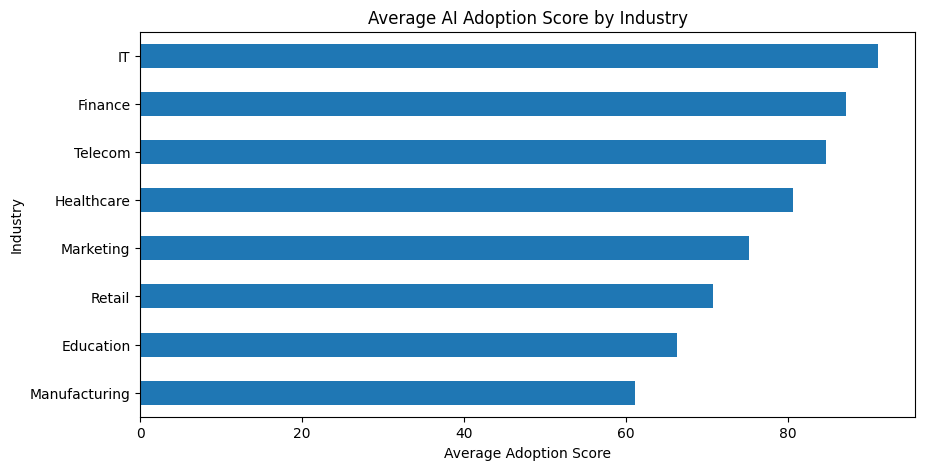

In [6]:
#avg adoption by industry
plt.figure(figsize=(10,5))

industry_avg.sort_values().plot(
    kind='barh'
)

plt.title("Average AI Adoption Score by Industry")
plt.xlabel("Average Adoption Score")
plt.show()

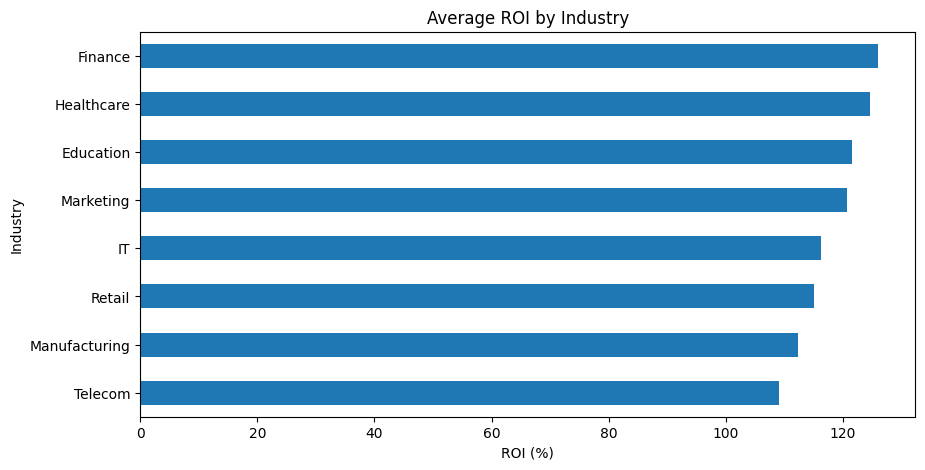

In [8]:
#Avg ROI by industry
roi_industry = df.groupby('Industry')['ROI_Percent'].mean()

plt.figure(figsize=(10,5))

roi_industry.sort_values().plot(
    kind='barh'
)

plt.title("Average ROI by Industry")
plt.xlabel("ROI (%)")
plt.show()

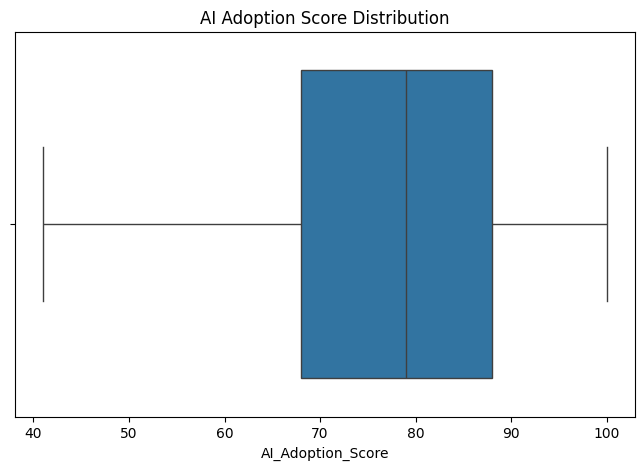

In [9]:
#Box plot for adoption score
plt.figure(figsize=(8,5))

sns.boxplot(
    x=df['AI_Adoption_Score']
)

plt.title("AI Adoption Score Distribution")
plt.show()

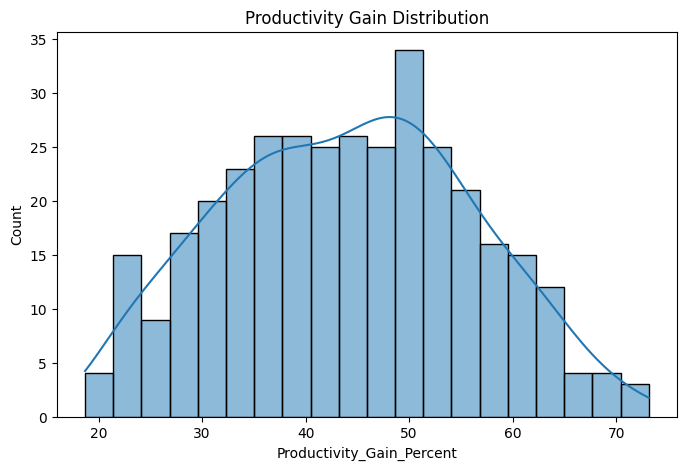

In [10]:
# Productivity Gain Distribution

plt.figure(figsize=(8,5))

sns.histplot(
    df['Productivity_Gain_Percent'],
    kde=True,
    bins=20
)

plt.title("Productivity Gain Distribution")
plt.show()

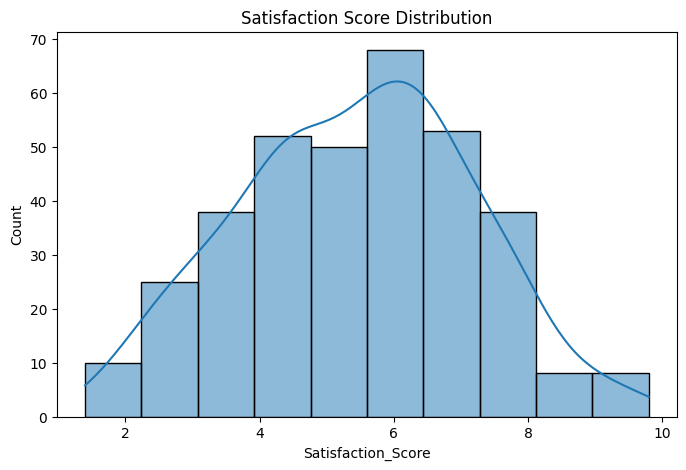

In [11]:
#Satisfaction score distribution
plt.figure(figsize=(8,5))

sns.histplot(
    df['Satisfaction_Score'],
    kde=True,
    bins=10
)

plt.title("Satisfaction Score Distribution")
plt.show()